In [3]:
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import argparse
# Removed: from IPython.display import Image, display # This will be imported in new display cells

# ── 1. Load Image ───────────────────────────────────
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    print(f"[INFO] Loaded image: {img.shape}")
    return img

# ── 2. Detect Face & Eye Region ───────────────────────────
def detect_eye_region(image):
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    gray  = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1,
                                          minNeighbors=5, minSize=(100, 100))

    if len(faces) == 0:
        raise RuntimeError("No face detected in the image.")

    # Pick the largest detected face
    fx, fy, fw, fh = sorted(faces, key=lambda r: r[2] * r[3])[-1]
    print(f"[INFO] Face detected at x={fx} y={fy} w={fw} h={fh}")

    # Eyes sit roughly 25–45 % down the face bounding box
    eye_top    = fy + int(fh * 0.25)
    eye_bottom = fy + int(fh * 0.45)
    eye_left   = fx + int(fw * 0.05)
    eye_right  = fx + int(fw * 0.95)

    print(f"[INFO] Eye ROI rows {eye_top}:{eye_bottom}, cols {eye_left}:{eye_right}")
    return eye_top, eye_bottom, eye_left, eye_right

# ── 3. Create Sunglass PNG (RGBA) ─────────────────────────
def make_sunglass(width, height):
    """Draws a two-lens sunglass with alpha transparency."""
    img = np.zeros((height, width, 4), dtype=np.uint8)

    cx_l  = int(width  * 0.27)   # left  lens centre x
    cx_r  = int(width  * 0.73)   # right lens centre x
    cy    = height // 2           # shared centre y
    rx    = int(width  * 0.22)   # lens radius x
    ry    = int(height * 0.38)   # lens radius y

    lens_color  = (20,  20,  20, 230)   # semi-opaque dark glass
    frame_color = (10,  10,  10, 255)   # solid black frame

    # Filled lenses
    cv2.ellipse(img, (cx_l, cy), (rx, ry), 0, 0, 360, lens_color,  -1)
    cv2.ellipse(img, (cx_r, cy), (rx, ry), 0, 0, 360, lens_color,  -1)

    # Lens outlines
    cv2.ellipse(img, (cx_l, cy), (rx, ry), 0, 0, 360, frame_color,  3)
    cv2.ellipse(img, (cx_r, cy), (rx, ry), 0, 0, 360, frame_color,  3)

    # Bridge between lenses
    bridge_y = cy - ry // 4 # Re-adding definition for bridge_y
    cv2.line(img, (cx_l + rx - 2, bridge_y), (cx_r - rx + 2, bridge_y), frame_color, 4)

    # Temple arms
    cv2.line(img, (cx_l - rx, cy), (0,         cy - 5), frame_color, 4)
    cv2.line(img, (cx_r + rx, cy), (width - 1, cy - 5), frame_color, 4)

    return img   # shape: (H, W, 4)  BGRA

# ── 4. Naive Replacement (Step 1 from notebook) ─────────────────
def apply_naive(face_img, glass_bgr, eye_top, eye_bottom, eye_left, eye_right):
    result = face_img.copy()
    result[eye_top:eye_bottom, eye_left:eye_right] = glass_bgr
    return result

# ── 5. Alpha-Masked Compositing (Step 2 from notebook) ───────────────
def apply_arithmetic(face_img, glass_bgr, glass_mask1,
                     eye_top, eye_bottom, eye_left, eye_right):
    # Build 3-channel mask and normalise to {0, 1}
    glass_mask = cv2.merge((glass_mask1, glass_mask1, glass_mask1))
    glass_mask = np.uint8(glass_mask / 255)

    result  = face_img.copy()
    eye_roi = result[eye_top:eye_bottom, eye_left:eye_right]

    # Mask out eye pixels where glass will sit
    masked_eye   = cv2.multiply(eye_roi,   (1 - glass_mask))
    # Keep only glass pixels
    masked_glass = cv2.multiply(glass_bgr, glass_mask)
    # Combine
    eye_final    = cv2.add(masked_eye, masked_glass)

    result[eye_top:eye_bottom, eye_left:eye_right] = eye_final
    return result, masked_eye, masked_glass, eye_final

# ── 6. Save Results ─────────────────────────────
def save_plots(face_img, naive_result, arith_result,
               masked_eye, masked_glass, eye_final, out_prefix="output"):

    # Intermediate steps
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    axes[0].imshow(masked_eye[..., ::-1]);   axes[0].set_title("Masked Eye Region",     fontsize=13)
    axes[1].imshow(masked_glass[..., ::-1]); axes[1].set_title("Masked Sunglass Region",fontsize=13)
    axes[2].imshow(eye_final[..., ::-1]);    axes[2].set_title("Augmented Eye+Sunglass", fontsize=13)
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    intermediate_path = f"{out_prefix}_intermediate.png"
    plt.savefig(intermediate_path)
    plt.close(fig)
    print(f"[INFO] Intermediate Plots saved to {intermediate_path}")

    # Final comparison
    fig2, axes2 = plt.subplots(1, 2, figsize=(18, 9))
    axes2[0].imshow(face_img[..., ::-1]);    axes2[0].set_title("Original Image",  fontsize=15)
    axes2[1].imshow(arith_result[..., ::-1]);axes2[1].set_title("With Sunglasses", fontsize=15)
    for ax in axes2: ax.axis('off')
    plt.suptitle("Sunglass Filter – Alpha Masking", fontsize=17, fontweight='bold')
    plt.tight_layout()
    final_path = f"{out_prefix}_final.png"
    plt.savefig(final_path)
    plt.close(fig2)
    print(f"[INFO] Final Plots saved to {final_path}")

In [4]:
# Execute the image processing pipeline
parser = argparse.ArgumentParser(description="Sunglass overlay experiment")
parser.add_argument("--image",  default="MYPHOTO.jpg", help="Path to face image")
parser.add_argument("--output", default="output",      help="Output file prefix")
args = parser.parse_args([]) # Pass empty list for Colab environment

face_img = load_image(args.image)
eye_top, eye_bottom, eye_left, eye_right = detect_eye_region(face_img)

glass_h = eye_bottom - eye_top
glass_w = eye_right  - eye_left

glass_png  = make_sunglass(glass_w, glass_h)
glass_bgr  = glass_png[:, :, 0:3]
glass_mask = glass_png[:, :, 3]

naive_result = apply_naive(face_img, glass_bgr, eye_top, eye_bottom, eye_left, eye_right)

arith_result, masked_eye, masked_glass, eye_final = apply_arithmetic(
    face_img, glass_bgr, glass_mask, eye_top, eye_bottom, eye_left, eye_right
)

[INFO] Loaded image: (531, 413, 3)
[INFO] Face detected at x=114 y=94 w=194 h=194
[INFO] Eye ROI rows 142:181, cols 123:298


In [5]:
# Display the generated plots
save_plots(face_img, naive_result, arith_result,
           masked_eye, masked_glass, eye_final, out_prefix=args.output)

[INFO] Intermediate Plots saved to output_intermediate.png
[INFO] Final Plots saved to output_final.png


Intermediate Plots:


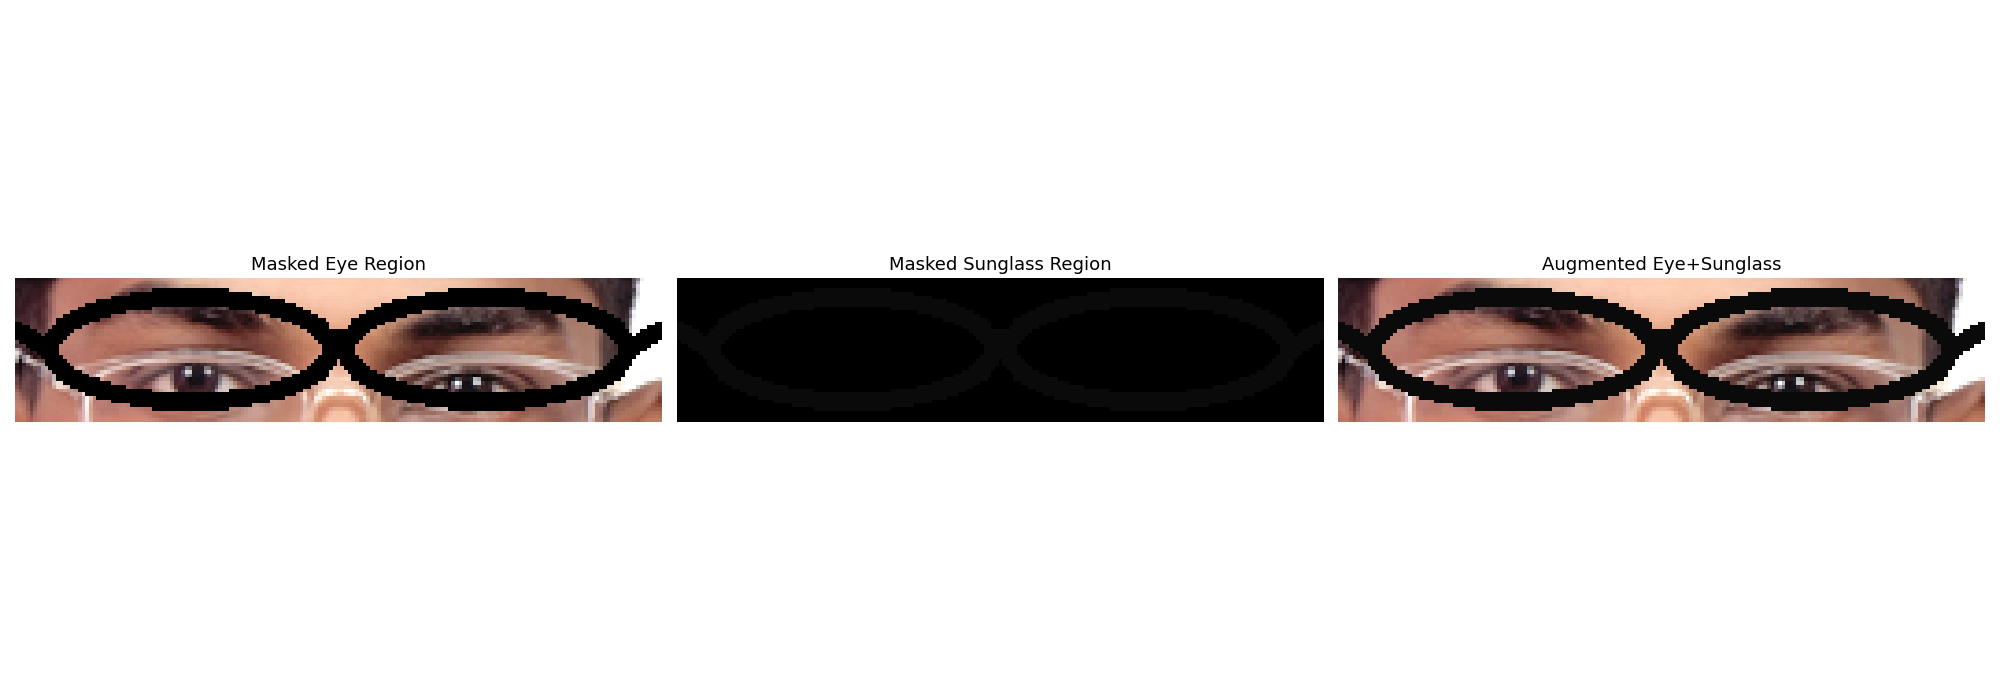

In [6]:
from IPython.display import Image, display
print("Intermediate Plots:")
display(Image('output_intermediate.png'))

Final Plots:


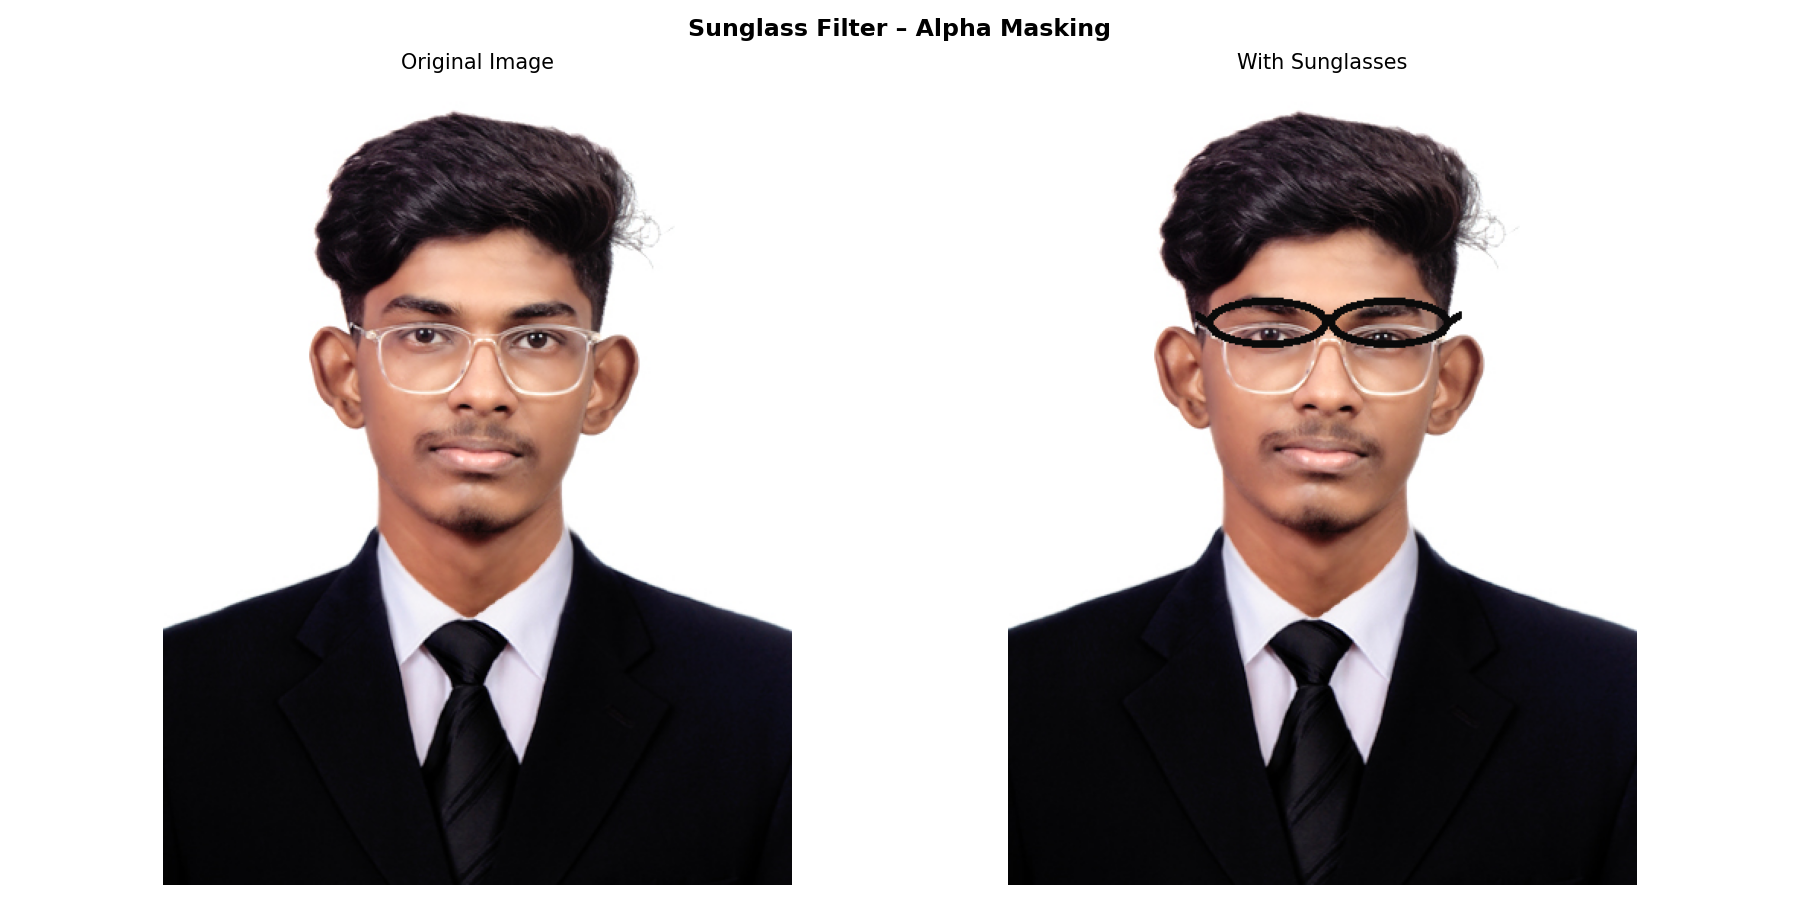

In [7]:
from IPython.display import Image, display
print("Final Plots:")
display(Image('output_final.png'))